# Introduction: Using the Kalman filter for prediction
The output from this notebook will be used to provide answers for this lesson's practice
quiz. It shows how to extend a Kalman filter to predict future states.

In [2]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

% Data file contains Ad Bd Cd Dd SigmaV SigmaW dT t u x z
load readonly/simOut.mat

### Implementing a Kalman filter for the prediction application
The next notebook cells implement the standard Kalman filter, augmented with steps that compute adjustments to predict the future state of the system.

In [3]:
% Initialize simulation variables
M = 6; % how many steps into the future to predict the state
useU = 1; % whether to use "future" u(k) in prediction

[nx,nt] = size(x); 
xhat = zeros(nx,1);     % Initialize Kalman filter initial estimate
SigmaX = zeros(nx,nx);  % Initialize Kalman filter covariance (part a)

% Reserve storage for variables we might want to plot/evaluate
xhatstore = zeros(nx,nt);
boundstore = xhatstore;
xhatstore(:,1) = xhat;
xhatPstore = zeros(nx,nt+M);
boundPstore = xhatPstore;

for k = 2:nt
  % KF Step 1a: State prediction time update      
  xhat = Ad*xhat + Bd*u(:,k-1); % use prior value of "u"

  % KF Step 1b: Prediction-error covariance time update
  SigmaX = Ad*SigmaX*Ad' + SigmaW;

  % KF Step 1c: Estimate system output
  zhat = Cd*xhat + Dd*u(k);

  % KF Step 2a: Compute Kalman gain matrix
  L = SigmaX*Cd'/(Cd*SigmaX*Cd' + SigmaV);

  % KF Step 2b: State estimate measurement update
  xhat = xhat + L*(z(k) - zhat);

  % KF Step 2c: Estimation-error covariance measurement update
  SigmaX = SigmaX - L*Cd*SigmaX;

  % Store estimate data for smoothing and KF output
  xhatstore(:,k) = xhat;
  boundstore(:,k) = 3*sqrt(diag(SigmaX));

  % Predict state M timesteps into future, along with bounds
  xhatPstore(:,k+M) = Ad^M * xhat;
  for  j = 0:M-1
    xhatPstore(:,k+M) = xhatPstore(:,k+M) + useU*Ad^(M-j-1)*Bd*u(:,min(nt,k+j));
  end
  SigmaXpred = Ad^M*SigmaX*(Ad^M)';
  for  j = 1:M
    SigmaXpred = SigmaXpred + Ad^j * SigmaW * (Ad^j)'; 
  end
  boundPstore(:,k+M) = 3*sqrt(diag(SigmaXpred));
end
xhatPstore = xhatPstore(:,1:nt);   % truncate at data length
boundPstore = boundPstore(:,1:nt);

### Plot simulation outputs 
The next notebook cells plot the state-vector estimates and predictions and the estimation errors and prediction errors (with bounds).

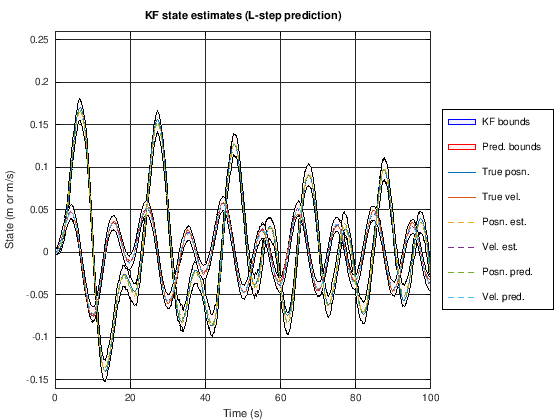

In [4]:
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [xhatstore-boundstore fliplr(xhatstore+boundstore)];
x3 = [xhatPstore-boundPstore fliplr(xhatPstore+boundPstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
h1b = fill(t2,x2(2,:),'b',"FaceAlpha",0.05); hold on; grid on
h3a = fill(t2,x3(1,:),'r',"FaceAlpha",0.05); hold on; grid on
h3b = fill(t2,x3(2,:),'r',"FaceAlpha",0.05); hold on; grid on
h2 = plot(t,x(1:2,:)',t,xhatstore(1:2,:)','--'); 
h4 = plot(t,xhatPstore(1:2,:)','--'); ylim([-0.16 0.26]);
legend([h2;h4;h1a;h3a],{'True posn.','True vel.','Posn. est.',...
  'Vel. est.','Posn. pred.','Vel. pred.','KF bounds','Pred. bounds'},'Location','EastOutside');
title('KF state estimates (L-step prediction)'); 
xlabel('Time (s)'); ylabel('State (m or m/s)'); 

bndErrFrac1 =  0.099900
bndErrFrac2 =  0.099900


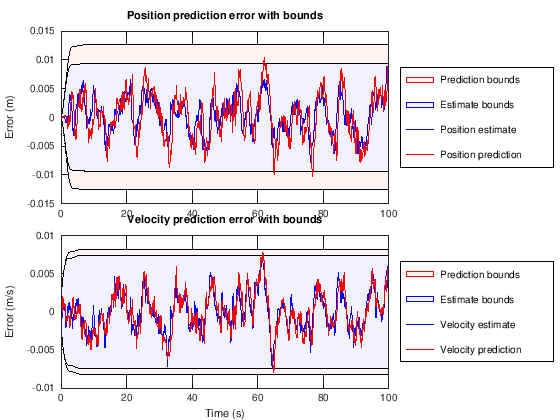

In [5]:
xerr = x - xhatstore; xPerr = x - xhatPstore;
xPerr(:,1:M) = 0; 
subplot(2,1,1); 
h1 = fill([t fliplr(t)],[-boundPstore(1,:) fliplr(boundPstore(1,:))],'r',...
  "FaceAlpha",0.05); hold on; grid on;
h2 = fill([t fliplr(t)],[-boundstore(1,:) fliplr(boundstore(1,:))],'b',...
  "FaceAlpha",0.05); 
h3 = plot(t,xerr(1,:),'b',t,xPerr(1,:),'r');
title('Position prediction error with bounds'); ylabel('Error (m)'); 
bndErrFrac1 = length(find(abs(xPerr(1,:))>boundPstore(1,:)))/nt*100
legend([h1;h2;h3],{'Prediction bounds','Estimate bounds','Position estimate','Position prediction'},'Location','EastOutside')

subplot(2,1,2); 
h1 = fill([t fliplr(t)],[-boundPstore(2,:) fliplr(boundPstore(2,:))],'r',...
  "FaceAlpha",0.05); hold on; grid on;
h2 = fill([t fliplr(t)],[-boundstore(2,:) fliplr(boundstore(2,:))],'b',...
  "FaceAlpha",0.05); 
h3 = plot(t,xerr(2,:),'b',t,xPerr(2,:),'r');
ht = title('Velocity prediction error with bounds'); 
hx = xlabel('Time (s)'); ylabel('Error (m/s)'); 
bndErrFrac2 = length(find(abs(xPerr(2,:))>boundPstore(2,:)))/nt*100
legend([h1;h2;h3],{'Prediction bounds','Estimate bounds','Velocity estimate','Velocity prediction'},'Location','EastOutside')